# Deep SARSA + Epistemic VAE + UCB cho ACB

Notebook này được triển khai theo luồng của `application/testing/new version/agent_training_acb.ipynb`, nhưng thay chiến lược chọn hành động greedy/epsilon-greedy bằng **UCB dựa trên độ bất định từ VAE**.

Luồng chính:
1. Nạp dữ liệu ACB và tính chỉ báo kỹ thuật giống notebook gốc.
2. Chia tập Good/Bad giống notebook gốc.
3. Định nghĩa lớp **EpistemicVAE** trong cell riêng.
4. Khởi tạo VAE và Replay Buffer; VAE được huấn luyện online song song với Deep SARSA để giảm distribution shift.
5. Huấn luyện Deep SARSA với policy **Q(s,a) + beta * u_ep(s,a)**, đồng thời cập nhật VAE từ replay buffer ở mỗi bước update Q.
6. So sánh random baseline, vẽ learning curve/percentile/portfolio, lưu model.

In [4]:
!git clone https://github.com/kohi-vip/SARSA_FinancialRL.git


Cloning into 'SARSA_FinancialRL'...
remote: Enumerating objects: 1367, done.
remote: Counting objects: 100% (345/345), done.
remote: Compressing objects: 100% (259/259), done.
remote: Total 1367 (delta 122), reused 280 (delta 79), pack-reused 1022 (from 2)
Receiving objects: 100% (1367/1367), 206.99 MiB | 38.79 MiB/s, done.
Resolving deltas: 100% (379/379), done.
Updating files: 100% (570/570), done.


In [19]:
%cd SARSA_FinancialRL

[Errno 2] No such file or directory: 'SARSA_FinancialRL'
/kaggle/working/SARSA_FinancialRL


In [20]:
import os
import sys
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
from torch import nn, optim
from torch.utils.data import DataLoader, Dataset, TensorDataset


# Tìm project root robust cho VS Code / Jupyter / cwd khác nhau
def find_project_root():
    cwd = Path.cwd().resolve()
    candidates = [cwd, cwd / 'SARSA_FinancialRL', *cwd.parents]
    for p in candidates:
        if (p / 'data').exists() and (p / 'environments').exists() and (p / 'agents').exists():
            return p
    raise FileNotFoundError('Không tìm thấy project root chứa data/, environments/, agents/.')

PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT))



SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PROJECT_ROOT =', PROJECT_ROOT)
print('DEVICE =', DEVICE)

PROJECT_ROOT = /kaggle/working/SARSA_FinancialRL
DEVICE = cuda


In [4]:
from data.data_processor.feature_engineer import engineer_stat as es
from environments.stock_trading_env.mdp import StockTradingMDP as stockMDP

# 1. Xử lý dữ liệu

In [5]:
# Tính chỉ báo kỹ thuật: MACD, RSI, CCI, ADX
# Version hiện tại của engineer_stat.add_technical_indicators không nhận
# vwap_period, fx_csv_path, corr_window. State của agent chỉ dùng 4 indicator này.
# Đã xóa phần tên bị lặp liền nhau
base_path = '/kaggle/working/SARSA_FinancialRL' 
csv_path = os.path.join(base_path, 'data', 'data_storer', 'data_research', 'HPG_data.csv')

df = pd.read_csv(csv_path)
df
start_date = pd.to_datetime('01-01-2013', format='%d-%m-%Y')

price_history = es.add_technical_indicators(
    df,
    start_date=start_date,
    auto_adjust_start_date=True,
    macd_fast=12,
    macd_slow=26,
    macd_signal=9,
    rsi_period=14,
    cci_period=20,
    adx_period=14,
)

# engineer_stat trả time dạng dd/mm/YYYY; chuyển lại datetime để split theo mốc ngày.
price_history['time'] = pd.to_datetime(price_history['time'], format='%d/%m/%Y')

print('=' * 80)
print('THÔNG TIN DỮ LIỆU SAU KHI THÊM CHỈ BÁO')
print('=' * 80)
print('Số cột:', len(price_history.columns))
print('Các cột:', price_history.columns.tolist())
print('Số dòng:', len(price_history))
print('\nNaN counts:')
nan_counts = price_history.isnull().sum()
print(nan_counts[nan_counts > 0])
price_history.head()

THÔNG TIN DỮ LIỆU SAU KHI THÊM CHỈ BÁO
Số cột: 10
Các cột: ['time', 'open', 'high', 'low', 'close', 'volume', 'MACD', 'RSI', 'CCI', 'ADX']
Số dòng: 2996

NaN counts:
Series([], dtype: int64)


,time,open,high,low,close,volume,MACD,RSI,CCI,ADX
0,2013-01-02,1.12,1.13,1.11,1.12,541540,0.033967,65.651683,133.838384,30.660577
1,2013-01-03,1.12,1.13,1.11,1.13,720080,0.034780,67.171896,122.897357,31.450804
2,2013-01-04,1.14,1.19,1.13,1.17,569620,0.038211,72.428490,173.722170,33.306400
3,2013-01-07,1.13,1.23,1.13,1.23,926020,0.045250,78.094607,196.341293,35.522421
4,2013-01-08,1.28,1.29,1.26,1.28,1480180,0.054238,81.505520,257.126236,38.108911


In [6]:
# Tính chỉ báo kỹ thuật giống agent_training_acb.ipynb
fx_csv_path = PROJECT_ROOT / 'data' / 'data_storer' / 'data_research' / 'USDVND_2013_2024.csv'
start_date = pd.to_datetime('01-01-2013', format='%d-%m-%Y')

price_history = es.add_technical_indicators(
     df,
    start_date=start_date,
    auto_adjust_start_date=True,
    macd_fast=12,
    macd_slow=26,
    macd_signal=9,
    rsi_period=14,
    cci_period=20,
    adx_period=14,
)

# Chuyển VWAP thành tỷ lệ tương đối như notebook gốc
if 'VWAP' in price_history.columns:
    price_history['VWAP'] = (price_history['close'] - price_history['VWAP']) / price_history['VWAP']

print('=' * 80)
print('THÔNG TIN DỮ LIỆU SAU KHI THÊM CHỈ BÁO')
print('=' * 80)
print('Số cột:', len(price_history.columns))
print('Các cột:', price_history.columns.tolist())
print('Số dòng:', len(price_history))
print('\nNaN counts:')
nan_counts = price_history.isnull().sum()
print(nan_counts[nan_counts > 0])
price_history.head()

THÔNG TIN DỮ LIỆU SAU KHI THÊM CHỈ BÁO
Số cột: 10
Các cột: ['time', 'open', 'high', 'low', 'close', 'volume', 'MACD', 'RSI', 'CCI', 'ADX']
Số dòng: 2996

NaN counts:
Series([], dtype: int64)


,time,open,high,low,close,volume,MACD,RSI,CCI,ADX
0,02/01/2013,1.12,1.13,1.11,1.12,541540,0.033967,65.651683,133.838384,30.660577
1,03/01/2013,1.12,1.13,1.11,1.13,720080,0.034780,67.171896,122.897357,31.450804
2,04/01/2013,1.14,1.19,1.13,1.17,569620,0.038211,72.428490,173.722170,33.306400
3,07/01/2013,1.13,1.23,1.13,1.23,926020,0.045250,78.094607,196.341293,35.522421
4,08/01/2013,1.28,1.29,1.26,1.28,1480180,0.054238,81.505520,257.126236,38.108911


In [7]:
# Chia dữ liệu theo Good/Bad period giống notebook gốc
price_history['time'] = pd.to_datetime(price_history['time'], format='%d/%m/%Y')

good_train_ACB = price_history[(price_history['time'] >= '2013-01-01') & (price_history['time'] <= '2018-12-31')].reset_index(drop=True)
good_test_ACB  = price_history[(price_history['time'] >= '2019-01-01') & (price_history['time'] <= '2021-12-31')].reset_index(drop=True)

bad_train_ACB = price_history[(price_history['time'] >= '2013-01-01') & (price_history['time'] <= '2021-12-31')].reset_index(drop=True)
bad_test_ACB  = price_history[(price_history['time'] >= '2022-01-01') & (price_history['time'] <= '2023-12-31')].reset_index(drop=True)

print(f'Good Train ACB: {len(good_train_ACB)} rows')
print(f'Good Test  ACB: {len(good_test_ACB)} rows')
print(f'Bad Train  ACB: {len(bad_train_ACB)} rows')
print(f'Bad Test   ACB: {len(bad_test_ACB)} rows')

Good Train ACB: 1496 rows
Good Test  ACB: 752 rows
Bad Train  ACB: 2248 rows
Bad Test   ACB: 498 rows


# 2. Baseline Random Policy

In [8]:
balance_init = 1000
k = 5
min_balance = -100
mdp = stockMDP(balance_init=balance_init, k=k, min_balance=min_balance)
A = mdp.A


def pi_random(s, greedy=False, eps=0.2):
    return int(np.random.choice(A))


def evaluate_random_baseline(train, test, num_runs=20):
    profits = []
    for _ in tqdm(range(num_runs), desc='Random baseline'):
        profit = mdp.interact_test(
            pi=pi_random,
            train_series=train,
            test_series=test,
            series_name='test',
            verbose=False,
        )
        profits.append(float(profit))
    print('Avg Profit', np.mean(profits))
    print('STD Profit', np.std(profits))
    return profits

random_profits_good = evaluate_random_baseline(good_train_ACB, good_test_ACB, num_runs=20)

Random baseline: 100%|██████████| 20/20 [00:01<00:00, 12.70it/s]

Avg Profit 786.8704760000003
STD Profit 632.7044038811989


# 3. VAE - Cell 1: định nghĩa lớp EpistemicVAE

VAE nhận cặp `(state, action_onehot)` và học tái cấu trúc lại vector này. Độ bất định epistemic dùng cho UCB được tính bằng:

`u_ep(s,a) = delta * KL(q(z|s,a) || N(0,I)) + lam * reconstruction_error_at_95_percentile`

Policy UCB sẽ chọn hành động theo `Q(s,a) + beta * u_ep(s,a)`.

In [9]:
class NumpyStandardScaler:
    def __init__(self, eps=1e-8):
        self.eps = eps
        self.mean_ = None
        self.std_ = None
        
    def fit(self, x):
        x = np.asarray(x, dtype=np.float32)
        self.mean_ = x.mean(axis=0)
        self.std_ = x.std(axis=0) + self.eps
        return self
        
    def transform(self, x):
        x = np.asarray(x, dtype=np.float32)
        return (x - self.mean_) / self.std_
        
    def fit_transform(self, x):
        return self.fit(x).transform(x)


class EpistemicVAE(nn.Module):
    def __init__(self, state_dim, action_dim, latent_dim=16):
        super().__init__()
        input_dim = state_dim + action_dim

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
        )
        self.fc_mu = nn.Linear(32, latent_dim)
        self.fc_logvar = nn.Linear(32, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim),
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, s, a_onehot):
        x = torch.cat([s, a_onehot], dim=-1)
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar

    def compute_u_ep(self, s, a_onehot, delta=1.0, lam=1.0):
        """Tính u_ep(s,a) cho một batch state/action đã scale."""
        x = torch.cat([s, a_onehot], dim=-1)
        mu, logvar = self.encode(x)
        kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=-1)
        std = torch.exp(0.5 * logvar)
        z_95 = mu + 1.96 * std
        x_recon_95 = self.decode(z_95)
        recon_err = torch.norm(x - x_recon_95, p=2, dim=-1)
        return delta * kl_div + lam * recon_err


def vae_loss(x_recon, x, mu, logvar, beta_kl=1e-3):
    """
    ELBO-style VAE loss:
    - Reconstruction MSE averaged over batch and input dimensions.
    - KL divergence summed over latent dimensions, then averaged over batch.
    """
    recon_loss = nn.functional.mse_loss(x_recon, x, reduction='mean')
    kld_per_sample = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp(),
        dim=-1,
    )
    kld = torch.mean(kld_per_sample)
    return recon_loss + beta_kl * kld, recon_loss.detach(), kld.detach()

# 4. VAE - Cell 2: Replay Buffer và khởi tạo Joint Training

**Không huấn luyện VAE offline một lần rồi cố định.** Cách đó dễ gây **distribution shift**: khi policy của Deep SARSA thay đổi, agent đi vào các vùng state/action mới mà VAE chưa từng thấy, làm `u_ep` phình lớn và khiến agent bị kẹt ở trạng thái khám phá.

Notebook này chuyển sang **joint training**:

1. Mỗi episode, Deep SARSA sinh trajectory bằng policy UCB hiện tại.
2. Các cặp `(state, action)` được đưa vào `VAEReplayBuffer`.
3. Khi cập nhật Q-network, đồng thời sample minibatch từ replay buffer để cập nhật VAE.
4. VAE thích ứng dần với phân phối state/action do policy hiện tại tạo ra.

Có bootstrap nhẹ bằng vài random trajectory ban đầu để UCB không dùng VAE hoàn toàn chưa warm-up ở episode đầu, nhưng VAE vẫn tiếp tục học online trong toàn bộ quá trình SARSA.

In [10]:
STATE_DIM = 7
ACTION_DIM = len(mdp.A)
ACTION_EMBED_DIM = 16


def initial_state_from_first_row(series, mdp):
    first_row = series.iloc[0]
    return [
        float(first_row['close']),
        mdp.balance_init,
        0,
        float(first_row['MACD']),
        float(first_row['RSI']),
        float(first_row['CCI']),
        float(first_row['ADX']),
    ]


def action_to_index(action, mdp):
    return int(action) + mdp.k


def actions_to_onehot(actions, mdp):
    idx = np.array([action_to_index(a, mdp) for a in actions], dtype=np.int64)
    onehot = np.zeros((len(idx), len(mdp.A)), dtype=np.float32)
    onehot[np.arange(len(idx)), idx] = 1.0
    return onehot
def normalize_u_ep_batch(u_ep_values):
    """
    Chuẩn hóa động u_ep để ép vào [1] dựa trên max của batch.
    Tự động nhận diện thiết bị (CPU/GPU) của tensor truyền vào.
    """
    max_u = torch.max(u_ep_values) + 1e-8
    return u_ep_values / max_u

def collect_vae_samples(train_series, mdp, num_trajectories=4):
    """Bootstrap nhẹ bằng random trajectories trên train, không dùng test."""
    all_states, all_actions = [], []
    state_init = initial_state_from_first_row(train_series, mdp)
    series = train_series.iloc[1:].reset_index(drop=True)

    for _ in range(num_trajectories):
        states, rewards, actions = mdp.simulate(series, state_init, pi_random, greedy=False, eps=1.0)
        all_states.extend(states[:-1])
        all_actions.extend(actions)

    return np.asarray(all_states, dtype=np.float32), np.asarray(all_actions, dtype=np.int64)


class VAEReplayBuffer:
    """Replay buffer lưu state/action để cập nhật VAE online cùng Deep SARSA."""
    def __init__(self, capacity=50_000):
        self.capacity = int(capacity)
        self.states = []
        self.actions = []

    def __len__(self):
        return len(self.actions)

    def add(self, states, actions):
        states = np.asarray(states, dtype=np.float32)
        actions = np.asarray(actions, dtype=np.int64)
        if len(states) != len(actions):
            raise ValueError(f'len(states)={len(states)} phải bằng len(actions)={len(actions)}')
        self.states.extend(states.tolist())
        self.actions.extend(actions.tolist())
        overflow = len(self.actions) - self.capacity
        if overflow > 0:
            self.states = self.states[overflow:]
            self.actions = self.actions[overflow:]

    def add_trajectory(self, states, actions):
        # mdp.simulate trả len(states) = len(actions) + 1
        self.add(states[:-1], actions)

    def sample(self, batch_size):
        if len(self) == 0:
            raise ValueError('VAEReplayBuffer rỗng, chưa thể sample.')
        size = min(int(batch_size), len(self))
        idx = np.random.choice(len(self), size=size, replace=False)
        states = np.asarray([self.states[i] for i in idx], dtype=np.float32)
        actions = np.asarray([self.actions[i] for i in idx], dtype=np.int64)
        return states, actions


def fit_scaler_from_bootstrap(train_series, mdp, num_trajectories=4):
    """Fit scaler chỉ từ train trajectories để tránh leakage từ test."""
    # Thu thập states và actions thô từ các episodes mồi
    states_np, actions_np = collect_vae_samples(train_series, mdp, num_trajectories=num_trajectories)
    scaler = NumpyStandardScaler()
    scaler.fit(states_np) # Đóng băng mean_ và std_ dựa trên tập huấn luyện thô
    return scaler, states_np, actions_np


def update_vae_from_replay(vae, vae_optimizer, replay_buffer, scaler, mdp, batch_size, beta_kl=1e-3):
    if len(replay_buffer) == 0:
        return None
    states_np, actions_np = replay_buffer.sample(batch_size)
    states_scaled = scaler.transform(states_np)
    actions_onehot = actions_to_onehot(actions_np, mdp)
    
    s_batch = torch.tensor(states_scaled, dtype=torch.float32, device=DEVICE)
    a_batch = torch.tensor(actions_onehot, dtype=torch.float32, device=DEVICE)
    
    vae.train()
    x_recon, mu, logvar = vae(s_batch, a_batch)
    x_true = torch.cat([s_batch, a_batch], dim=-1)
    
    # Đã sửa: Truyền beta_kl nhận từ đối số vào đây để đồng bộ
    loss, recon_loss, kld = vae_loss(x_recon, x_true, mu, logvar, beta_kl=beta_kl)
    
    vae_optimizer.zero_grad()
    loss.backward()
    vae_optimizer.step()
    return {
        'loss': float(loss.detach().cpu().item()),
        'recon_loss': float(recon_loss.detach().cpu().item()),
        'kld': float(kld.detach().cpu().item()),
    }

def initialize_joint_vae_components(
    train_series,
    mdp,
    latent_dim=16,
    vae_lr=1e-3,
    replay_capacity=50_000,
    bootstrap_trajectories=4,
    bootstrap_vae_updates=100,
    vae_batch_size=128,
    vae_beta_kl=1e-3,
    verbose=False,
):
    """Khởi tạo VAE + scaler + replay buffer cho joint training."""
    scaler, states_np, actions_np = fit_scaler_from_bootstrap(
        train_series, mdp, num_trajectories=bootstrap_trajectories
    )
    replay_buffer = VAEReplayBuffer(capacity=replay_capacity)
    replay_buffer.add(states_np, actions_np)

    vae = EpistemicVAE(state_dim=STATE_DIM, action_dim=len(mdp.A), latent_dim=latent_dim).to(DEVICE)
    vae_optimizer = optim.Adam(vae.parameters(), lr=vae_lr)
    bootstrap_losses = []

    for _ in range(int(bootstrap_vae_updates)):
        stats = update_vae_from_replay(
            vae, vae_optimizer, replay_buffer, scaler, mdp,
            batch_size=vae_batch_size,
            beta_kl=vae_beta_kl,
        )
        if stats is not None:
            bootstrap_losses.append(stats['loss'])

    if verbose and bootstrap_losses:
        plt.figure(figsize=(8, 4))
        plt.plot(bootstrap_losses)
        plt.title('EpistemicVAE Bootstrap Warm-up Loss')
        plt.xlabel('Update')
        plt.ylabel('Loss')
        plt.grid(alpha=0.3)
        plt.show()

    return vae, vae_optimizer, scaler, replay_buffer, bootstrap_losses

# 5. Deep SARSA với chiến lược UCB từ VAE

Khác với notebook gốc dùng epsilon-greedy, policy mới chọn hành động trong training theo:

`a = argmax_a Q(s,a) + beta * u_ep(s,a)`

Khi `greedy=True` trong đánh giá, policy chỉ dùng `argmax Q(s,a)` để đo hiệu suất khai thác sau huấn luyện.

In [11]:
class QsaUCB(nn.Module):
    def __init__(self, input_size=STATE_DIM, num_classes=11):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes),
        )

    def forward(self, x):
        return self.net(x)

class UCBVAEPolicy:
    def __init__(self, qsa, mdp, vae, scaler, beta=0.5, delta=1.0, lam=1.0, beta_decay=0.97, beta_min=0.01, episode_max=35):
        self.qsa = qsa
        self.mdp = mdp
        self.vae = vae
        self.scaler = scaler
        self.beta_init = beta
        self.beta = beta
        self.beta_decay = beta_decay
        self.beta_min = beta_min
        self.episode_max = episode_max
        self.delta = delta
        self.lam = lam

    def update_beta_decay(self, episode):
        """Cập nhật beta theo cơ chế giảm dần theo episode."""
        self.beta = max(self.beta_init * (self.beta_decay ** episode), self.beta_min)

    def scaled_state_tensor(self, s):
        s_np = np.asarray(s, dtype=np.float32).reshape(1, -1)
        s_scaled = self.scaler.transform(s_np)
        return torch.tensor(s_scaled, dtype=torch.float32, device=DEVICE)

    def __call__(self, s, greedy=False, eps=0.0):
        self.qsa.eval()
        self.vae.eval()
        with torch.no_grad():
            s_tensor = self.scaled_state_tensor(s) # Shape: [1, state_dim]
            q_values = self.qsa(s_tensor).squeeze(0) # Shape: [num_actions]
            
            if greedy:
                best_action_idx = int(torch.argmax(q_values).item())
                return int(self.mdp.A[best_action_idx])
            
            num_actions = len(self.mdp.A)
            
            # --- TỐI ƯU HÓA VECTOR HÓA (BATCHING) ---
            # 1. Nhân bản trạng thái s thành một batch có num_actions dòng
            # s_tensor: [1, state_dim] -> s_batch: [num_actions, state_dim]
            s_batch = s_tensor.repeat(num_actions, 1)
            
            # 2. Tạo batch One-hot cho toàn bộ hành động bằng ma trận đơn vị Identity
            # a_onehot_batch: [num_actions, num_actions] (mỗi dòng là một vector One-hot)
            a_onehot_batch = torch.eye(num_actions, dtype=torch.float32, device=DEVICE)
            
            # 3. Tính u_ep cho toàn bộ 11 hành động trong 1 lần gọi duy nhất (Không dùng vòng lặp Python)
            # u_ep_tensor: [num_actions]
            u_ep_tensor = self.vae.compute_u_ep(s_batch, a_onehot_batch, delta=self.delta, lam=self.lam)
            
            # 4. Chuẩn hóa động u_ep để ép vào [1]
            u_ep_normalized = normalize_u_ep_batch(u_ep_tensor) # Shape: [num_actions]
            
            # 5. Công thức chọn hành động UCB: Q(s,a) + beta * u_ep_norm
            ucb_tensor = q_values + self.beta * u_ep_normalized # Shape: [num_actions]
            
            # Lấy index của hành động có giá trị UCB cao nhất
            best_action_idx = int(torch.argmax(ucb_tensor).item())
            
            # Trả về hành động thực tế đã được ánh xạ ngược lại mdp.A
            return int(self.mdp.A[best_action_idx])


class ScaledStatesDataset(Dataset):
    """
    Dataset transition đúng theo trajectory on-policy:
    (s_t, a_t, r_t, s_{t+1}, a_{t+1}, done_t).

    Việc lưu a_{t+1} ngay trong dataset tránh lỗi lệch next-action tại
    ranh giới minibatch. Transition cuối cùng được đánh dấu terminal,
    vì vậy Q(s_{T+1}, a_{T+1}) không được cộng vào target.
    """
    def __init__(self, states, rewards, actions, scaler):
        states_np = np.asarray(states, dtype=np.float32)
        rewards_np = np.asarray(rewards, dtype=np.float32)
        actions_np = np.asarray(actions, dtype=np.int64)

        if len(states_np) != len(actions_np) + 1:
            raise ValueError(
                f'Expected len(states)=len(actions)+1, got '
                f'{len(states_np)} states and {len(actions_np)} actions.'
            )
        if len(rewards_np) != len(actions_np):
            raise ValueError(
                f'Expected len(rewards)=len(actions), got '
                f'{len(rewards_np)} rewards and {len(actions_np)} actions.'
            )

        next_actions_np = np.empty_like(actions_np)
        if len(actions_np) > 1:
            next_actions_np[:-1] = actions_np[1:]
        if len(actions_np) > 0:
            next_actions_np[-1] = actions_np[-1]  # placeholder; bị triệt tiêu bởi done=1

        dones_np = np.zeros(len(actions_np), dtype=np.float32)
        if len(dones_np) > 0:
            dones_np[-1] = 1.0

        self.states = torch.tensor(
            scaler.transform(states_np[:-1]),
            dtype=torch.float32,
        )
        self.states_next = torch.tensor(
            scaler.transform(states_np[1:]),
            dtype=torch.float32,
        )
        self.rewards = torch.tensor(rewards_np, dtype=torch.float32)
        self.actions = torch.tensor(actions_np, dtype=torch.long)
        self.next_actions = torch.tensor(next_actions_np, dtype=torch.long)
        self.dones = torch.tensor(dones_np, dtype=torch.float32)

    def __len__(self):
        return len(self.rewards)

    def __getitem__(self, idx):
        return {
            'states': self.states[idx],
            'states_next': self.states_next[idx],
            'rewards': self.rewards[idx],
            'actions': self.actions[idx],
            'next_actions': self.next_actions[idx],
            'dones': self.dones[idx],
        }


def train_deep_sarsa_ucb_vae(
    mdp,
    train_series,
    test_series,
    vae,
    vae_optimizer,
    vae_buffer,
    scaler,
    episodes=35,
    gamma=0.95,
    alpha=0.6,
    nn_epochs=10,
    nn_lr=1e-5,
    beta=0.5,
    delta=1.0,
    lam=1.0,
    vae_batch_size=128,
    vae_updates_per_q_batch=1,
    vae_beta_kl=1e-3,
    beta_decay=0.97,
    beta_min=0.01,
    verbose=False,
):
    qsa = QsaUCB(input_size=STATE_DIM, num_classes=len(mdp.A)).to(DEVICE)
    optimizer = optim.Adam(qsa.parameters(), lr=nn_lr)
    loss_func = nn.HuberLoss()
    policy = UCBVAEPolicy(qsa=qsa, mdp=mdp, vae=vae, scaler=scaler, beta=beta, delta=delta, lam=lam, 
                          beta_decay=beta_decay, beta_min=beta_min, episode_max=episodes)

    state_init = initial_state_from_first_row(train_series, mdp)
    series = train_series.iloc[1:].reset_index(drop=True)
    learning_curve, losses, vae_losses, beta_history = [], [], [], []

    if verbose:
        print('=' * 80)
        print('TRAINING DEEP SARSA-UCB-VAE AGENT WITH JOINT VAE TRAINING + BETA DECAY')
        print('=' * 80)
        print(f'Episodes={episodes}, gamma={gamma}, alpha={alpha}, nn_epochs={nn_epochs}, nn_lr={nn_lr}')
        print(f'UCB beta_init={beta}, beta_decay={beta_decay}, beta_min={beta_min}')
        print(f'Epistemic: delta={delta}, lam={lam}')
        print(f'VAE replay size init={len(vae_buffer)}, vae_batch_size={vae_batch_size}, updates_per_q_batch={vae_updates_per_q_batch}')

    for epi in tqdm(range(episodes), desc='Training Deep SARSA-UCB-VAE', disable=not verbose):
        # Cập nhật beta theo cơ chế decay
        policy.update_beta_decay(epi)
        beta_history.append(policy.beta)
        
        qsa.eval()
        vae.eval()
        states, rewards, actions = mdp.simulate(series, state_init, policy, greedy=False, eps=0.0)

        # Joint training: thêm trajectory mới từ policy hiện tại vào replay buffer.
        vae_buffer.add_trajectory(states, actions)

        dataset = ScaledStatesDataset(states, rewards, actions, scaler)
        dataloader = DataLoader(dataset, batch_size=128, shuffle=False)

        qsa.train()
        for _ in range(nn_epochs):
            for data_pack in dataloader:
                s_batch = data_pack['states'].to(DEVICE)
                sn_batch = data_pack['states_next'].to(DEVICE)
                r_batch = data_pack['rewards'].to(DEVICE)
                actions_batch = data_pack['actions'].to(DEVICE)
                next_actions_batch = data_pack['next_actions'].to(DEVICE)
                done_batch = data_pack['dones'].to(DEVICE)

                action_indices = actions_batch + mdp.k
                next_action_indices = next_actions_batch + mdp.k

                q_values = qsa(s_batch)
                current_q = q_values.gather(
                    1, action_indices.view(-1, 1)
                ).squeeze(1)

                with torch.no_grad():
                    next_q_values = qsa(sn_batch)
                    next_q = next_q_values.gather(
                        1, next_action_indices.view(-1, 1)
                    ).squeeze(1)

                    # Deep SARSA on-policy target:
                    # y_t = r_t + gamma * (1-done_t) * Q(s_{t+1}, a_{t+1})
                    target_q = r_batch + gamma * (1.0 - done_batch) * next_q

                    # Giữ Bellman smoothing của nghiên cứu gốc.
                    target_tensor = (
                        (1.0 - alpha) * current_q.detach()
                        + alpha * target_q
                    )

                loss = loss_func(current_q, target_tensor)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                losses.append(float(loss.detach().cpu().item()))

                # Cập nhật VAE song song mỗi khi update Q.
                for _vae_step in range(int(vae_updates_per_q_batch)):
                    stats = update_vae_from_replay(
                        vae, vae_optimizer, vae_buffer, scaler, mdp,
                        batch_size=vae_batch_size,
                        beta_kl=vae_beta_kl,
                    )
                    if stats is not None:
                        vae_losses.append(stats['loss'])

        profit = mdp.interact_test(policy, train_series=train_series, test_series=test_series, series_name='test', verbose=False)
        learning_curve.append(float(profit))

    if verbose:
        print(f'Final Q loss: {losses[-1]:.6f}' if losses else 'No Q loss')
        print(f'Final VAE loss: {vae_losses[-1]:.6f}' if vae_losses else 'No VAE loss')
        fig, axes = plt.subplots(1, 3, figsize=(20, 5))
        axes[0].plot(losses, alpha=0.8)
        axes[0].set_title('Deep SARSA-UCB-VAE Q Loss')
        axes[0].grid(alpha=0.3)
        axes[1].plot(vae_losses, alpha=0.8, color='purple')
        axes[1].set_title('Online VAE Loss')
        axes[1].grid(alpha=0.3)
        axes[2].plot(learning_curve, marker='o')
        axes[2].set_title('Deep SARSA-UCB-VAE Learning Curve')
        axes[2].set_xlabel('Episode')
        axes[2].set_ylabel('Profit')
        axes[2].grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

    return policy, qsa, learning_curve, vae_losses

# 6. Hàm chạy thí nghiệm và metrics

In [12]:
def collect_portfolio_history(mdp, pi, train_series, test_series):
    prev_row = train_series.iloc[-1]
    state_init = [
        float(prev_row['close']), mdp.balance_init, 0,
        float(prev_row['MACD']), float(prev_row['RSI']), float(prev_row['CCI']), float(prev_row['ADX'])
    ]
    states, rewards, actions = mdp.simulate(test_series, state_init, pi, greedy=True, eps=0.0)
    portfolio = np.array([s[1] + s[0] * s[2] for s in states], dtype=np.float32)
    return portfolio, states, actions


def calculate_volatility(portfolio_history):
    values = np.asarray(portfolio_history, dtype=np.float32)
    returns = np.diff(values) / np.maximum(values[:-1], 1e-8)
    return float(np.std(returns) * np.sqrt(252) * 100) if len(returns) else 0.0


def calculate_sharpe_ratio(portfolio_history, risk_free_rate=2.0):
    values = np.asarray(portfolio_history, dtype=np.float32)
    returns = np.diff(values) / np.maximum(values[:-1], 1e-8)
    if len(returns) == 0 or np.std(returns) == 0:
        return 0.0
    annual_return = np.mean(returns) * 252 * 100
    volatility = np.std(returns) * np.sqrt(252) * 100
    return float((annual_return - risk_free_rate) / volatility) if volatility > 0 else 0.0


def calculate_max_drawdown(portfolio_history):
    values = np.asarray(portfolio_history, dtype=np.float32)
    peak = np.maximum.accumulate(values)
    drawdown = (values - peak) / np.maximum(peak, 1e-8)
    return float(abs(drawdown.min()) * 100) if len(drawdown) else 0.0


def agent_annual_return(initial_capital, final_portfolio, start_date, end_date):
    total_return = (final_portfolio / initial_capital) - 1
    years = (pd.to_datetime(end_date) - pd.to_datetime(start_date)).days / 365.25
    if years <= 0:
        return 0.0, 0.0
    annual = (1 + total_return) ** (1 / years) - 1
    return annual * 100, total_return * 100


def run_ucb_vae_experiment(train, test, config, num_runs=20, label='good'):
    all_final_profits = []
    all_learning_curves = []
    all_portfolio_histories = []
    best = None

    for run in tqdm(range(num_runs), desc=f'Running Deep SARSA-UCB-VAE {label}'):
        # Mỗi run có VAE/replay buffer riêng để tránh nhiễu giữa các lần chạy.
        vae, vae_optimizer, scaler, vae_buffer, bootstrap_losses = initialize_joint_vae_components(
            train_series=train,
            mdp=mdp,
            latent_dim=config.get('vae_latent_dim', 16),
            vae_lr=config.get('vae_lr', 1e-3),
            replay_capacity=config.get('vae_replay_capacity', 50_000),
            bootstrap_trajectories=config.get('bootstrap_trajectories', 4),
            bootstrap_vae_updates=config.get('bootstrap_vae_updates', 100),
            vae_batch_size=config.get('vae_batch_size', 128),
            vae_beta_kl=config.get('vae_beta_kl', 1e-3),
            verbose=False,
        )

        policy, qsa, learning_curve, vae_losses = train_deep_sarsa_ucb_vae(
            mdp=mdp,
            train_series=train,
            test_series=test,
            vae=vae,
            vae_optimizer=vae_optimizer,
            vae_buffer=vae_buffer,
            scaler=scaler,
            episodes=config['episodes'],
            gamma=config['gamma'],
            alpha=config['alpha'],
            nn_epochs=config['nn_epochs'],
            nn_lr=config['nn_lr'],
            beta=config['beta'],
            delta=config['delta'],
            lam=config['lam'],
            vae_batch_size=config.get('vae_batch_size', 128),
            vae_updates_per_q_batch=config.get('vae_updates_per_q_batch', 1),
            vae_beta_kl=config.get('vae_beta_kl', 1e-3),
            beta_decay=config.get('beta_decay', 0.97),
            beta_min=config.get('beta_min', 0.01),
            verbose=False,
        )
        final_profit = mdp.interact_test(policy, train_series=train, test_series=test, series_name='test', verbose=False)
        portfolio_history, states, actions = collect_portfolio_history(mdp, policy, train, test)

        all_final_profits.append(float(final_profit))
        all_learning_curves.append(learning_curve)
        all_portfolio_histories.append(portfolio_history)

        if best is None or final_profit > best['final_profit']:
            best = {
                'policy': policy,
                'qsa': qsa,
                'vae': vae,
                'vae_scaler': scaler,
                'vae_losses': vae_losses,
                'bootstrap_vae_losses': bootstrap_losses,
                'learning_curve': learning_curve,
                'final_profit': float(final_profit),
                'portfolio_history': portfolio_history,
                'states': states,
                'actions': actions,
            }

        print(f'Run {run + 1:02d}/{num_runs} - {label} - final profit: {final_profit:.2f}')

    mean_curve = np.mean(np.asarray(all_learning_curves, dtype=np.float32), axis=0)
    std_curve = np.std(np.asarray(all_learning_curves, dtype=np.float32), axis=0)
    mean_portfolio = np.mean(np.asarray(all_portfolio_histories, dtype=np.float32), axis=0)

    result = {
        'agent': 'Deep SARSA-UCB-VAE (Joint VAE Training)',
        'final_profit': float(np.mean(all_final_profits)),
        'std_final_profit': float(np.std(all_final_profits)),
        'all_final_profits': all_final_profits,
        'learning_curve': mean_curve,
        'std_learning_curve': std_curve,
        'all_learning_curves': all_learning_curves,
        'best_policy': best['policy'],
        'trained_agent': best['qsa'],
        'trained_vae': best['vae'],
        'vae_scaler': best['vae_scaler'],
        'vae_losses': best['vae_losses'],
        'bootstrap_vae_losses': best['bootstrap_vae_losses'],
        'portfolio_history': mean_portfolio,
        'best_portfolio_history': best['portfolio_history'],
        'all_portfolio_histories': all_portfolio_histories,
        'states': best['states'],
        'actions': best['actions'],
        'roi': float(np.mean(all_final_profits) / mdp.balance_init * 100),
        'volatility': calculate_volatility(mean_portfolio),
        'sharpe_ratio': calculate_sharpe_ratio(mean_portfolio),
        'max_drawdown': calculate_max_drawdown(mean_portfolio),
    }
    return result


def print_result_summary(res, random_profits, test, title):
    start_date = test.iloc[0]['time']
    end_date = test.iloc[-1]['time']
    final_portfolio = balance_init + res['final_profit']
    annual_rate, total_rate = agent_annual_return(balance_init, final_portfolio, start_date, end_date)

    print('\n' + '=' * 80)
    print(title)
    print('=' * 80)
    print(f"Agent: {res['agent']}")
    print(f"  • Average Final Profit: ${res['final_profit']:.2f} ± ${res['std_final_profit']:.2f}")
    print(f"  • Best Profit: ${np.max(res['all_final_profits']):.2f}")
    print(f"  • Worst Profit: ${np.min(res['all_final_profits']):.2f}")
    print(f"  • Peak Training Profit: ${np.max(res['learning_curve']):.2f}")
    print(f"  • ROI: {res['roi']:.2f}%")
    print(f"  • Annual Return Rate: {annual_rate:.2f}%")
    print(f"  • Total Return Rate: {total_rate:.2f}%")
    print(f"  • Volatility: {res['volatility']:.2f}%")
    print(f"  • Sharpe Ratio: {res['sharpe_ratio']:.4f}")
    print(f"  • Max Drawdown: {res['max_drawdown']:.2f}%")
    print('\nRandom Policy Baseline:')
    print(f"  • Average Profit: ${np.mean(random_profits):.2f} ± ${np.std(random_profits):.2f}")

In [21]:
train = good_train_ACB
test = good_test_ACB
shared_config_ucb_vae = {
    'episodes': 45,       
    'gamma': 0.88,        # GIẢM từ 0.95 xuống 0.88: Giúp Agent "thực tế" hơn, tập trung bảo vệ danh mục trước mắt thay vì mơ mộng gồng lỗ dài hạn.
    
    # --- ỔN ĐỊNH HÓA XUNG LỰC HỌC TẬP CỦA CRITIC ---
    'alpha': 0.3,         # GIẢM từ 1.0 xuống 0.3: Giúp Critic tích lũy tri thức mượt mà, giảm nhiễu phiên và triệt tiêu biến động cực đại của Q-values.
    'nn_epochs': 1,       
    'nn_lr': 5.0e-5,      # TĂNG nhẹ lên 5e-5: Cho phép mạng nơ-ron cập nhật trọng số nhanh hơn một chút để thích ứng với cú sốc đảo chiều vĩ mô.
    
    # --- THẮT CHẶT LỰC KHÁM PHÁ TRONG DOWNMARKET ---
    'beta': 0.15,         # Sửa lại thử ở các beta = [0.8; 0.85; 0.9]
    'delta': 1.0,  
    'lam': 1.0,    
    'beta_decay': 0.85,   # GIẢM từ 0.91 xuống 0.85: Thúc đẩy Agent nhanh chóng chuyển dịch sang chính sách an toàn (Exploitation) từ tập thứ 15-20.
    'beta_min': 0.01,     

    # Joint VAE training config
    'vae_latent_dim': 16, 
    'vae_lr': 1e-3,       
    'vae_beta_kl': 1e-3,  # ĐƯA VỀ 1e-3 (chuẩn của bài báo gốc): Tránh ép quá chặt không gian ẩn để VAE ước lượng Epistemic chính xác hơn.
    'vae_batch_size': 128,
    'vae_updates_per_q_batch': 1, 
    'vae_replay_capacity': 50_000,
    
    # --- ĐỊNH VỊ PHÂN PHỐI VỮNG CHẮC ---
    'bootstrap_trajectories': 5,  
    'bootstrap_vae_updates': 100,
}
print("--- BẮT ĐẦU KIỂM THỬ DRY-RUN TRÊN GPU ---")
# --- BẮT ĐẦU KIỂM THỬ DRY-RUN TRÊN GPU ---
print("--- BẮT ĐẦU KIỂM THỬ DRY-RUN TRÊN GPU ---")
try:
    # 1. Khởi tạo scaler và VAE thử nghiệm (SỬA DÒNG NÀY ĐỂ UNPACK TUPLE)
    dummy_scaler, _, _ = fit_scaler_from_bootstrap(train, mdp, num_trajectories=2)
    
    dummy_vae, dummy_vae_opt, _, dummy_buffer, _ = initialize_joint_vae_components(
        train_series=train,
        mdp=mdp,
        latent_dim=16,
        vae_lr=1e-3,
        replay_capacity=1000,
        bootstrap_trajectories=2,
        bootstrap_vae_updates=10,
        verbose=False
    )
    dummy_vae = dummy_vae.to(DEVICE)
    
    # 2. Khởi tạo Q-network thử nghiệm
    dummy_qsa = QsaUCB(input_size=7, num_classes=len(mdp.A)).to(DEVICE)
    
    # 3. Khởi tạo Policy tối ưu hóa mới (đã vector hóa)
    optimized_policy = UCBVAEPolicy(
        qsa=dummy_qsa,
        mdp=mdp,
        vae=dummy_vae,
        scaler=dummy_scaler,
        beta=shared_config_ucb_vae['beta']
    )
    
    # 4. Chạy thử simulate chọn hành động cho 1 trạng thái mẫu
    sample_state = [100.0, 5.0, 0.0, 0.1, 50.0, 120.0, 44.0]  # 7 features trạng thái mẫu
    action = optimized_policy(sample_state)
    
    print(f"✅ Kiểm thử thành công! Hành động robot chọn ra: {action}")
    print(f"⚡ Thiết bị phần cứng đang xử lý: {next(dummy_vae.parameters()).device}")
    print("--- BẠN ĐÃ SẴN SÀNG CHẠY TIẾN TRÌNH HUẤN LUYỆN CHÍNH THỨC! ---")
except Exception as e:
    print(f"❌ Có lỗi xảy ra trong quá trình dry-run: {e}")

--- BẮT ĐẦU KIỂM THỬ DRY-RUN TRÊN GPU ---
--- BẮT ĐẦU KIỂM THỬ DRY-RUN TRÊN GPU ---
✅ Kiểm thử thành công! Hành động robot chọn ra: 4
⚡ Thiết bị phần cứng đang xử lý: cuda:0
--- BẠN ĐÃ SẴN SÀNG CHẠY TIẾN TRÌNH HUẤN LUYỆN CHÍNH THỨC! ---


# 7. Huấn luyện trên Good period

In [14]:
"""

train = good_train_ACB
test = good_test_ACB

result_good_ucb_vae = run_ucb_vae_experiment(train, test, shared_config_ucb_vae, num_runs=10, label='good')
results_good = {'ucb_vae': result_good_ucb_vae}

print_result_summary(
    result_good_ucb_vae,
    random_profits_good,
    test,
    title='FINAL RESULTS SUMMARY - ACB GOOD - DEEP SARSA + JOINT VAE + UCB',
)
"""

"\n\ntrain = good_train_ACB\ntest = good_test_ACB\n\nresult_good_ucb_vae = run_ucb_vae_experiment(train, test, shared_config_ucb_vae, num_runs=10, label='good')\nresults_good = {'ucb_vae': result_good_ucb_vae}\n\nprint_result_summary(\n    result_good_ucb_vae,\n    random_profits_good,\n    test,\n    title='FINAL RESULTS SUMMARY - ACB GOOD - DEEP SARSA + JOINT VAE + UCB',\n)\n"

In [15]:
"""def plot_ucb_results(result, test, title_suffix='', color='blue'):
    plt.figure(figsize=(12, 5))
    plt.plot(result['learning_curve'], label='Deep SARSA-UCB-VAE', linewidth=2, color=color)
    plt.title(f'Learning Curve - {title_suffix}')
    plt.xlabel('Episode')
    plt.ylabel('Profit ($)')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

    percentile_levels = np.arange(0, 101, 5)
    percentile_values = np.percentile(result['all_final_profits'], percentile_levels)
    plt.figure(figsize=(10, 6))
    plt.plot(percentile_levels, percentile_values, marker='o', linewidth=2, label='UCB + VAE', color=color)
    plt.title(f'Độ biến thiên hiệu suất qua mỗi vòng lặp - {title_suffix}')
    plt.xlabel('Percentile (%)')
    plt.ylabel('Profit ($)')
    plt.xticks(percentile_levels)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

    port = result['portfolio_history']
    plt.figure(figsize=(14, 6))
    plt.plot(test['time'], port[1:], label='UCB + VAE', linewidth=2, color=color)
    plt.title(f'Portfolio Value Over Time - {title_suffix}')
    plt.xlabel('Time')
    plt.ylabel('Portfolio Value ($)')
    plt.xticks(rotation=45)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_ucb_results(result_good_ucb_vae, good_test_ACB, title_suffix='ACB Good Period - UCB + VAE', color='blue')
"""

"def plot_ucb_results(result, test, title_suffix='', color='blue'):\n    plt.figure(figsize=(12, 5))\n    plt.plot(result['learning_curve'], label='Deep SARSA-UCB-VAE', linewidth=2, color=color)\n    plt.title(f'Learning Curve - {title_suffix}')\n    plt.xlabel('Episode')\n    plt.ylabel('Profit ($)')\n    plt.grid(alpha=0.3)\n    plt.legend()\n    plt.show()\n\n    percentile_levels = np.arange(0, 101, 5)\n    percentile_values = np.percentile(result['all_final_profits'], percentile_levels)\n    plt.figure(figsize=(10, 6))\n    plt.plot(percentile_levels, percentile_values, marker='o', linewidth=2, label='UCB + VAE', color=color)\n    plt.title(f'Độ biến thiên hiệu suất qua mỗi vòng lặp - {title_suffix}')\n    plt.xlabel('Percentile (%)')\n    plt.ylabel('Profit ($)')\n    plt.xticks(percentile_levels)\n    plt.grid(alpha=0.3)\n    plt.legend()\n    plt.show()\n\n    port = result['portfolio_history']\n    plt.figure(figsize=(14, 6))\n    plt.plot(test['time'], port[1:], label='UCB + 

# 8. Huấn luyện trên Bad period

VAE được huấn luyện lại trên `bad_train_ACB` để tránh leakage từ tập test.


Với joint training, mỗi run sẽ tự khởi tạo VAE/replay buffer riêng từ `bad_train_ACB` và cập nhật VAE online cùng Deep SARSA. Không dùng dữ liệu test và không dùng lại VAE từ Good period.

In [22]:
random_profits_bad = evaluate_random_baseline(bad_train_ACB, bad_test_ACB, num_runs=20)

train = bad_train_ACB
test = bad_test_ACB

result_bad_ucb_vae = run_ucb_vae_experiment(train, test, shared_config_ucb_vae, num_runs=10, label='bad')
results_bad = {'ucb_vae': result_bad_ucb_vae}

print_result_summary(
    result_bad_ucb_vae,
    random_profits_bad,
    test,
    title='FINAL RESULTS SUMMARY - ACB BAD - DEEP SARSA + JOINT VAE + UCB',
)

Random baseline: 100%|██████████| 20/20 [00:01<00:00, 18.03it/s]


Avg Profit -91.38293700000034
STD Profit 158.67589655880317


Running Deep SARSA-UCB-VAE bad:  10%|█         | 1/10 [02:31<22:44, 151.65s/it]

Run 01/10 - bad - final profit: 22.87


Running Deep SARSA-UCB-VAE bad:  20%|██        | 2/10 [04:54<19:33, 146.74s/it]

...

Run 08/10 - bad - final profit: 64.50


Running Deep SARSA-UCB-VAE bad:  90%|█████████ | 9/10 [22:00<02:26, 146.69s/it]

Run 09/10 - bad - final profit: 11.11


Running Deep SARSA-UCB-VAE bad: 100%|██████████| 10/10 [24:24<00:00, 146.46s/it]

Run 10/10 - bad - final profit: 49.83

FINAL RESULTS SUMMARY - ACB BAD - DEEP SARSA + JOINT VAE + UCB
Agent: Deep SARSA-UCB-VAE (Joint VAE Training)
  • Average Final Profit: $1.18 ± $126.49
  • Best Profit: $180.37
  • Worst Profit: $-284.50
  • Peak Training Profit: $13.66
  • ROI: 0.12%
  • Annual Return Rate: 0.06%
  • Total Return Rate: 0.12%
  • Volatility: 16.39%
  • Sharpe Ratio: -0.0365
  • Max Drawdown: 33.77%

Random Policy Baseline:
  • Average Profit: $-91.38 ± $158.68


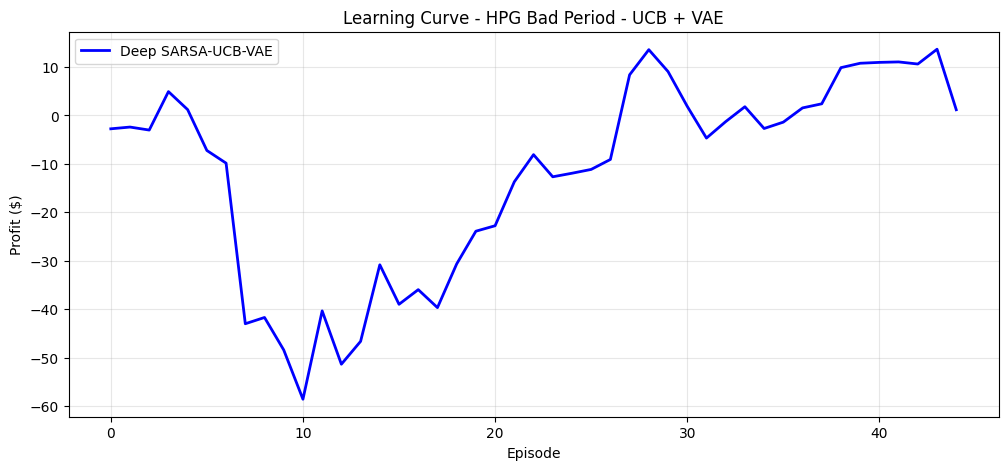

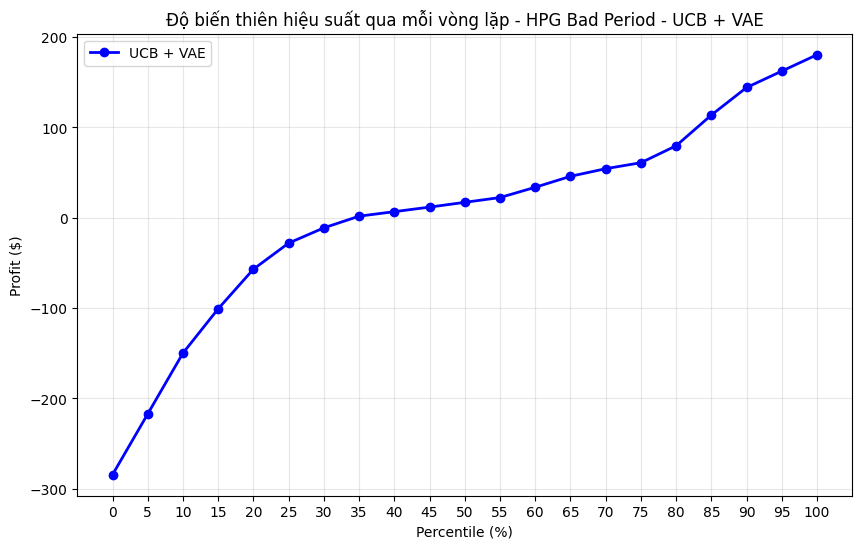

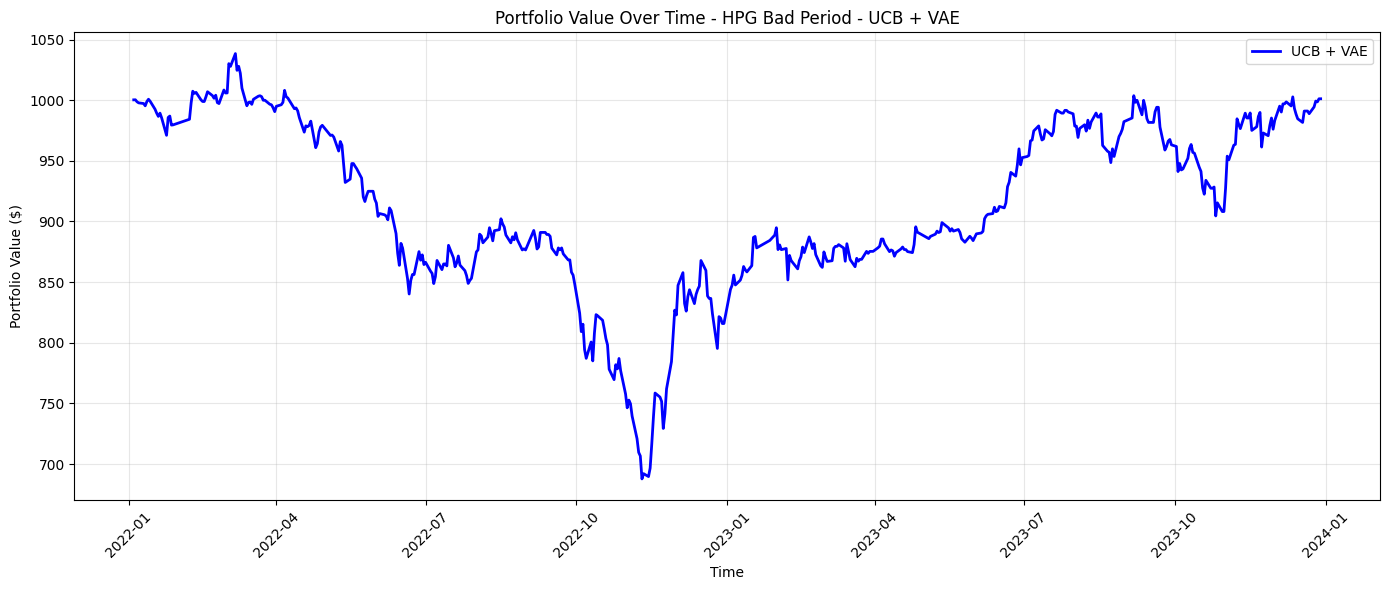

In [23]:
def plot_ucb_results(result, test, title_suffix='', color='blue'):
    plt.figure(figsize=(12, 5))
    plt.plot(result['learning_curve'], label='Deep SARSA-UCB-VAE', linewidth=2, color=color)
    plt.title(f'Learning Curve - {title_suffix}')
    plt.xlabel('Episode')
    plt.ylabel('Profit ($)')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

    percentile_levels = np.arange(0, 101, 5)
    percentile_values = np.percentile(result['all_final_profits'], percentile_levels)
    plt.figure(figsize=(10, 6))
    plt.plot(percentile_levels, percentile_values, marker='o', linewidth=2, label='UCB + VAE', color=color)
    plt.title(f'Độ biến thiên hiệu suất qua mỗi vòng lặp - {title_suffix}')
    plt.xlabel('Percentile (%)')
    plt.ylabel('Profit ($)')
    plt.xticks(percentile_levels)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

    port = result['portfolio_history']
    plt.figure(figsize=(14, 6))
    plt.plot(test['time'], port[1:], label='UCB + VAE', linewidth=2, color=color)
    plt.title(f'Portfolio Value Over Time - {title_suffix}')
    plt.xlabel('Time')
    plt.ylabel('Portfolio Value ($)')
    plt.xticks(rotation=45)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_ucb_results(result_bad_ucb_vae, bad_test_ACB, title_suffix='HPG Bad Period - UCB + VAE', color='blue')

# 9. Beta sensitivity analysis (3 runs per value)

Cell dưới đây giữ nguyên toàn bộ cấu hình trong `shared_config_ucb_vae` và chỉ thay đổi **initial UCB beta** theo dãy:

`[0.10, 0.13, 0.15, 0.17, 0.20]`

Mỗi beta được chạy 3 lần với cùng chuỗi random seed để tăng tính công bằng giữa các cấu hình. Đây là một **screening experiment**; 3 lần chạy chỉ đủ quan sát xu hướng và kiểm tra liệu beta = 0.15 có phải local optimum trong lưới thử nghiệm hay không, chưa đủ để khẳng định cực trị thống kê.


In [21]:
import copy
import gc
from pathlib import Path

# ============================================================
# BETA-ONLY SENSITIVITY SWEEP
# Giữ nguyên mọi tham số trong shared_config_ucb_vae,
# chỉ thay initial beta.
# ============================================================

BETA_VALUES = [0.10, 0.13, 0.15, 0.17, 0.20]
BETA_SWEEP_RUNS = 3
BETA_SWEEP_SEED = 20260713

# Chọn rõ Bad period để cell này có thể chạy độc lập sau cell cấu hình,
# không cần chạy lại cell huấn luyện 10 lần ở phía trên.
SWEEP_TRAIN = bad_train_ACB
SWEEP_TEST = bad_test_ACB


def set_experiment_seed(seed):
    """Đặt lại toàn bộ RNG để các beta dùng cùng chuỗi seed."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)


def sample_std(values):
    values = np.asarray(values, dtype=np.float64)
    return float(np.std(values, ddof=1)) if len(values) > 1 else 0.0


def mean_and_std(values):
    values = np.asarray(values, dtype=np.float64)
    return float(np.mean(values)), sample_std(values)


beta_sweep_records = []
beta_sweep_raw_results = {}

start_date = SWEEP_TEST.iloc[0]['time']
end_date = SWEEP_TEST.iloc[-1]['time']
initial_capital = float(mdp.balance_init)

print('=' * 90)
print('BETA SENSITIVITY ANALYSIS - DEEP SARSA + JOINT VAE + UCB')
print('=' * 90)
print(f'Beta values       : {BETA_VALUES}')
print(f'Runs per beta     : {BETA_SWEEP_RUNS}')
print(f'Fixed beta_decay  : {shared_config_ucb_vae["beta_decay"]}')
print(f'Fixed beta_min    : {shared_config_ucb_vae["beta_min"]}')
print(f'Other parameters  : unchanged from shared_config_ucb_vae')
print()

for beta_value in BETA_VALUES:
    # Common-random-number design:
    # mỗi beta bắt đầu từ cùng RNG state để giảm nhiễu so sánh.
    set_experiment_seed(BETA_SWEEP_SEED)

    beta_config = copy.deepcopy(shared_config_ucb_vae)
    beta_config['beta'] = float(beta_value)

    print('-' * 90)
    print(
        f'Running beta={beta_value:.2f} '
        f'({BETA_SWEEP_RUNS} independent runs)'
    )

    result = run_ucb_vae_experiment(
        train=SWEEP_TRAIN,
        test=SWEEP_TEST,
        config=beta_config,
        num_runs=BETA_SWEEP_RUNS,
        label=f'beta_{beta_value:.2f}',
    )
    beta_sweep_raw_results[beta_value] = result

    final_profits = np.asarray(
        result['all_final_profits'],
        dtype=np.float64,
    )
    portfolio_histories = result['all_portfolio_histories']

    # Tính các financial metrics trên TỪNG run rồi mới tổng hợp.
    # Cách này tránh metric-of-average bias.
    run_roi = final_profits / initial_capital * 100.0
    run_arr = []
    run_total_return = []
    run_volatility = []
    run_sharpe = []
    run_max_drawdown = []

    for final_profit, portfolio_history in zip(
        final_profits,
        portfolio_histories,
    ):
        annual_rate, total_rate = agent_annual_return(
            initial_capital=initial_capital,
            final_portfolio=initial_capital + float(final_profit),
            start_date=start_date,
            end_date=end_date,
        )
        run_arr.append(annual_rate)
        run_total_return.append(total_rate)
        run_volatility.append(
            calculate_volatility(portfolio_history)
        )
        run_sharpe.append(
            calculate_sharpe_ratio(portfolio_history)
        )
        run_max_drawdown.append(
            calculate_max_drawdown(portfolio_history)
        )

    avg_profit, std_profit = mean_and_std(final_profits)
    avg_roi, std_roi = mean_and_std(run_roi)
    avg_arr, std_arr = mean_and_std(run_arr)
    avg_total, std_total = mean_and_std(run_total_return)
    avg_vol, std_vol = mean_and_std(run_volatility)
    avg_sharpe, std_sharpe = mean_and_std(run_sharpe)
    avg_mdd, std_mdd = mean_and_std(run_max_drawdown)

    beta_sweep_records.append({
        'Beta': float(beta_value),
        'Runs': int(BETA_SWEEP_RUNS),
        'Average Final Profit': avg_profit,
        'Std Final Profit': std_profit,
        'Best Final Profit': float(np.max(final_profits)),
        'Worst Final Profit': float(np.min(final_profits)),
        'Average ROI (%)': avg_roi,
        'Std ROI (%)': std_roi,
        'Average ARR (%)': avg_arr,
        'Std ARR (%)': std_arr,
        'Average Total Return (%)': avg_total,
        'Std Total Return (%)': std_total,
        'Average Volatility (%)': avg_vol,
        'Std Volatility (%)': std_vol,
        'Average Sharpe Ratio': avg_sharpe,
        'Std Sharpe Ratio': std_sharpe,
        'Average Max Drawdown (%)': avg_mdd,
        'Std Max Drawdown (%)': std_mdd,
    })

    print(
        f'Completed beta={beta_value:.2f}: '
        f'Profit={avg_profit:.2f} ± {std_profit:.2f}, '
        f'ARR={avg_arr:.2f}%, '
        f'Sharpe={avg_sharpe:.4f}, '
        f'MDD={avg_mdd:.2f}%'
    )

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


beta_sweep_df = (
    pd.DataFrame(beta_sweep_records)
    .sort_values('Beta')
    .reset_index(drop=True)
)

print('\n' + '=' * 90)
print('BETA SWEEP RESULT TABLE')
print('=' * 90)
display(beta_sweep_df.round(4))

# ------------------------------------------------------------
# Kiểm tra beta=0.15 có phải local optimum trong lưới hay không.
# "Tốt" được hiểu riêng theo từng metric:
# - Maximize: Profit, ROI, ARR, Total Return, Sharpe
# - Minimize: Volatility, Max Drawdown
# ------------------------------------------------------------
beta_indexed = beta_sweep_df.set_index('Beta')
target_beta = 0.15
left_beta = 0.13
right_beta = 0.17

local_checks = {}

if all(b in beta_indexed.index for b in [left_beta, target_beta, right_beta]):
    maximize_metrics = [
        'Average Final Profit',
        'Average ROI (%)',
        'Average ARR (%)',
        'Average Total Return (%)',
        'Average Sharpe Ratio',
    ]
    minimize_metrics = [
        'Average Volatility (%)',
        'Average Max Drawdown (%)',
    ]

    for metric in maximize_metrics:
        center = beta_indexed.loc[target_beta, metric]
        local_checks[metric] = bool(
            center > beta_indexed.loc[left_beta, metric]
            and center > beta_indexed.loc[right_beta, metric]
        )

    for metric in minimize_metrics:
        center = beta_indexed.loc[target_beta, metric]
        local_checks[metric] = bool(
            center < beta_indexed.loc[left_beta, metric]
            and center < beta_indexed.loc[right_beta, metric]
        )

print('\nLOCAL-OPTIMUM CHECK AT beta=0.15')
print('-' * 90)
for metric, passed in local_checks.items():
    print(f'{metric:<32}: {"YES" if passed else "NO"}')

profit_best_beta = float(
    beta_sweep_df.loc[
        beta_sweep_df['Average Final Profit'].idxmax(),
        'Beta',
    ]
)
sharpe_best_beta = float(
    beta_sweep_df.loc[
        beta_sweep_df['Average Sharpe Ratio'].idxmax(),
        'Beta',
    ]
)
mdd_best_beta = float(
    beta_sweep_df.loc[
        beta_sweep_df['Average Max Drawdown (%)'].idxmin(),
        'Beta',
    ]
)

print('\nGLOBAL BEST WITHIN THE TESTED GRID')
print('-' * 90)
print(f'Best beta by Average Final Profit : {profit_best_beta:.2f}')
print(f'Best beta by Average Sharpe Ratio : {sharpe_best_beta:.2f}')
print(f'Best beta by lowest Max Drawdown  : {mdd_best_beta:.2f}')

if profit_best_beta == target_beta:
    print(
        '\nBeta=0.15 is the best tested value by Average Final Profit.'
    )
else:
    print(
        f'\nBeta=0.15 is not the best tested value by Average Final Profit; '
        f'the current best is beta={profit_best_beta:.2f}.'
    )

print(
    '\nImportant: with only 3 runs per beta, this result is a preliminary '
    'sensitivity screen, not statistical proof of a true optimum.'
)

# Save artifacts for later review.
output_dir = Path(
    globals().get(
        'OUTPUT_ROOT',
        Path.cwd() / 'ucb_vae_beta_sweep',
    )
)
output_dir.mkdir(parents=True, exist_ok=True)
beta_sweep_csv = output_dir / 'beta_sweep_3_runs.csv'
beta_sweep_df.to_csv(beta_sweep_csv, index=False)
print(f'\nSaved beta sweep table to: {beta_sweep_csv}')


BETA SENSITIVITY ANALYSIS - DEEP SARSA + JOINT VAE + UCB
Beta values       : [0.1, 0.13, 0.15, 0.17, 0.2]
Runs per beta     : 3
Fixed beta_decay  : 0.88
Fixed beta_min    : 0.01
Other parameters  : unchanged from shared_config_ucb_vae

------------------------------------------------------------------------------------------
Running beta=0.10 (3 independent runs)


Running Deep SARSA-UCB-VAE beta_0.10:  33%|███▎      | 1/3 [02:24<04:48, 144.16s/it]

Run 01/3 - beta_0.10 - final profit: -113.66


Running Deep SARSA-UCB-VAE beta_0.10:  67%|██████▋   | 2/3 [04:52<02:26, 146.45s/it]

Run 02/3 - beta_0.10 - final profit: -168.54


...

Run 02/3 - beta_0.20 - final profit: -168.54


Running Deep SARSA-UCB-VAE beta_0.20: 100%|██████████| 3/3 [07:23<00:00, 147.71s/it]

Run 03/3 - beta_0.20 - final profit: -216.97
Completed beta=0.20: Profit=-174.27 ± 40.14, ARR=-9.23%, Sharpe=-0.2328, MDD=53.15%

BETA SWEEP RESULT TABLE


,Beta,Runs,Average Final Profit,Std Final Profit,Best Final Profit,Worst Final Profit,Average ROI (%),Std ROI (%),Average ARR (%),Std ARR (%),Average Total Return (%),Std Total Return (%),Average Volatility (%),Std Volatility (%),Average Sharpe Ratio,Std Sharpe Ratio,Average Max Drawdown (%),Std Max Drawdown (%)
0,0.10,3,-156.2225,37.9319,-113.6629,-186.4657,-15.6223,3.7932,-8.2280,2.0721,-15.6223,3.7932,32.3829,13.4102,-0.1903,0.1578,52.7343,20.0208
1,0.13,3,-120.0420,94.6265,-10.9984,-180.5887,-12.0042,9.4627,-6.3357,5.0161,-12.0042,9.4627,30.7544,15.5885,-0.1145,0.1112,48.9841,25.0189
2,0.15,3,-114.8238,142.5662,46.7970,-222.7296,-11.4824,14.2566,-6.1645,7.5159,-11.4824,14.2566,30.4099,16.5559,-0.0763,0.2039,48.3002,27.6622
3,0.17,3,-156.0034,29.3054,-122.5152,-176.9562,-15.6003,2.9305,-8.2098,1.6010,-15.6003,2.9305,32.2872,13.4259,-0.1944,0.1676,52.4909,20.1565
4,0.20,3,-174.2727,40.1414,-137.3066,-216.9727,-17.4273,4.0141,-9.2265,2.2330,-17.4273,4.0141,32.4600,13.4257,-0.2328,0.1955,53.1511,20.0692



LOCAL-OPTIMUM CHECK AT beta=0.15
------------------------------------------------------------------------------------------
Average Final Profit            : YES
Average ROI (%)                 : YES
Average ARR (%)                 : YES
Average Total Return (%)        : YES
Average Sharpe Ratio            : YES
Average Volatility (%)          : YES
Average Max Drawdown (%)        : YES

GLOBAL BEST WITHIN THE TESTED GRID
------------------------------------------------------------------------------------------
Best beta by Average Final Profit : 0.15
Best beta by Average Sharpe Ratio : 0.15
Best beta by lowest Max Drawdown  : 0.15

Beta=0.15 is the best tested value by Average Final Profit.

Important: with only 3 runs per beta, this result is a preliminary sensitivity screen, not statistical proof of a true optimum.

Saved beta sweep table to: /kaggle/working/SARSA_FinancialRL/ucb_vae_beta_sweep/beta_sweep_3_runs.csv


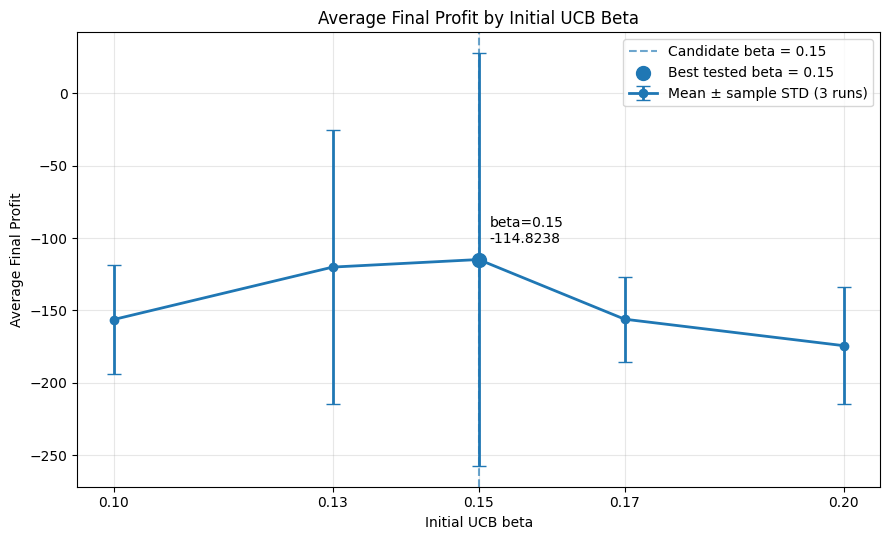

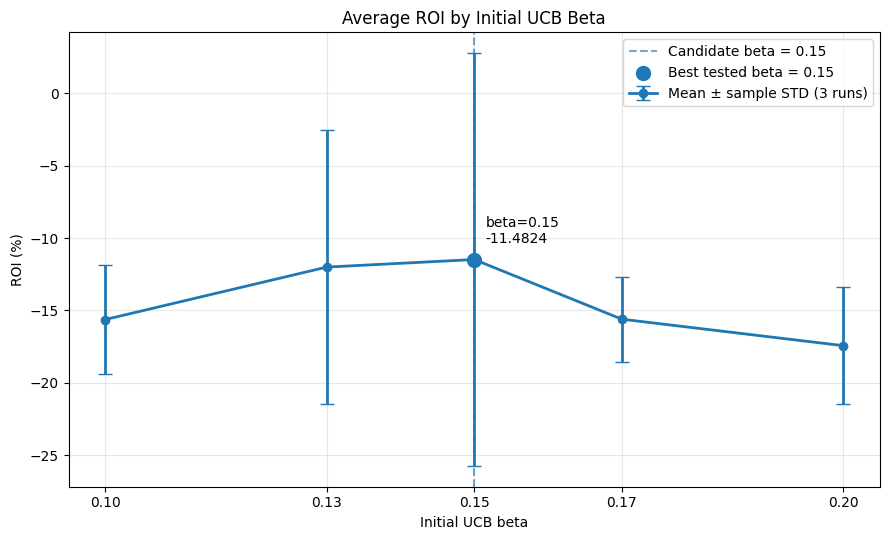

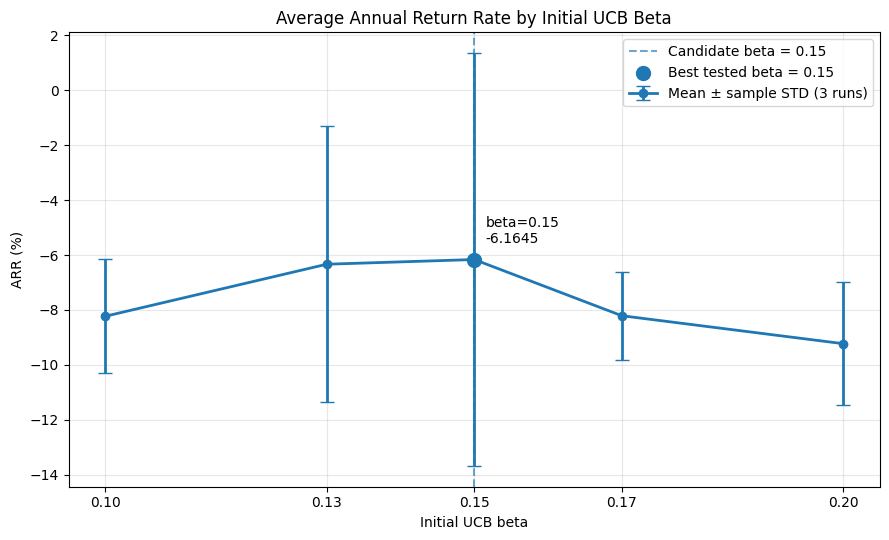

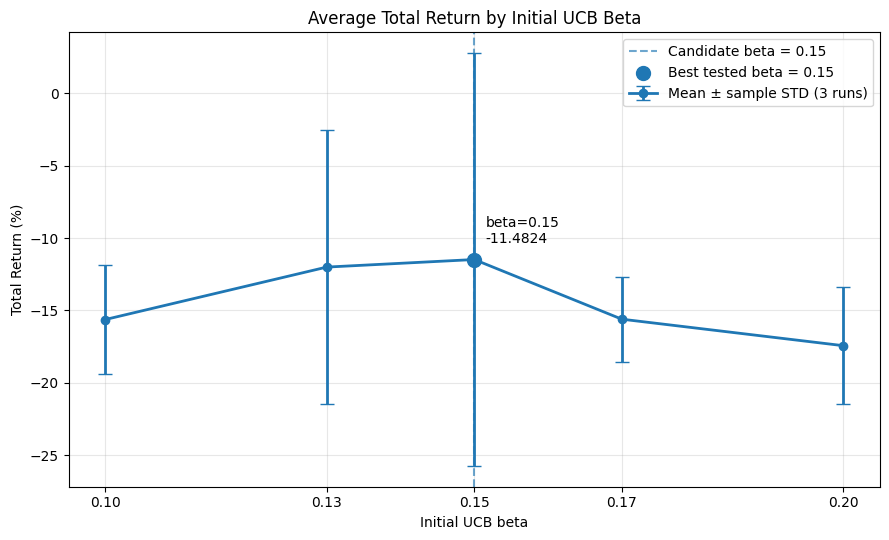

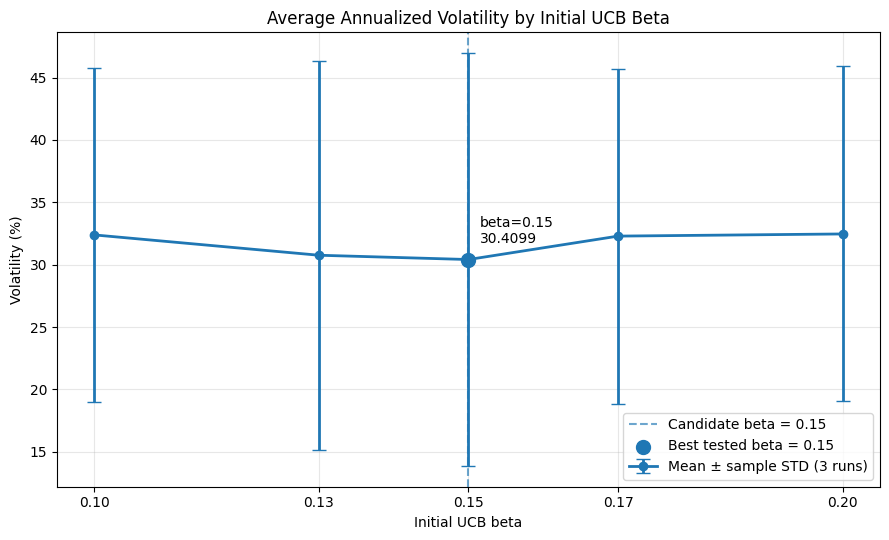

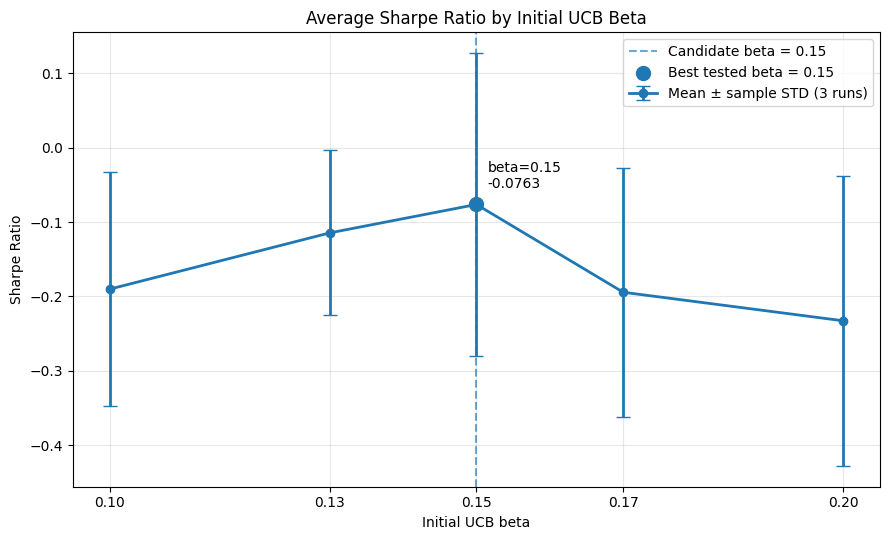

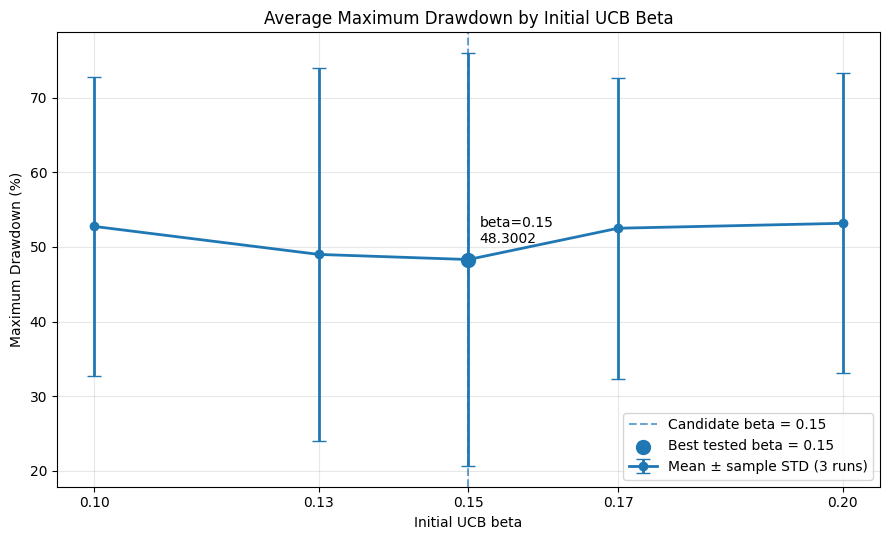

COMPACT BETA-SWEEP SUMMARY


,Beta,Average Final Profit,Average ARR (%),Average Volatility (%),Average Sharpe Ratio,Average Max Drawdown (%)
0,0.10,-156.2225,-8.2280,32.3829,-0.1903,52.7343
1,0.13,-120.0420,-6.3357,30.7544,-0.1145,48.9841
2,0.15,-114.8238,-6.1645,30.4099,-0.0763,48.3002
3,0.17,-156.0034,-8.2098,32.2872,-0.1944,52.4909
4,0.20,-174.2727,-9.2265,32.4600,-0.2328,53.1511


In [22]:
# ============================================================
# BETA SWEEP VISUALIZATION
# Mỗi metric được vẽ trong một figure riêng để tránh trộn thang đo.
# ============================================================

if 'beta_sweep_df' not in globals() or beta_sweep_df.empty:
    raise RuntimeError(
        'Hãy chạy cell Beta sensitivity analysis trước cell này.'
    )

plot_specs = [
    {
        'mean': 'Average Final Profit',
        'std': 'Std Final Profit',
        'title': 'Average Final Profit by Initial UCB Beta',
        'ylabel': 'Average Final Profit',
        'mode': 'max',
    },
    {
        'mean': 'Average ROI (%)',
        'std': 'Std ROI (%)',
        'title': 'Average ROI by Initial UCB Beta',
        'ylabel': 'ROI (%)',
        'mode': 'max',
    },
    {
        'mean': 'Average ARR (%)',
        'std': 'Std ARR (%)',
        'title': 'Average Annual Return Rate by Initial UCB Beta',
        'ylabel': 'ARR (%)',
        'mode': 'max',
    },
    {
        'mean': 'Average Total Return (%)',
        'std': 'Std Total Return (%)',
        'title': 'Average Total Return by Initial UCB Beta',
        'ylabel': 'Total Return (%)',
        'mode': 'max',
    },
    {
        'mean': 'Average Volatility (%)',
        'std': 'Std Volatility (%)',
        'title': 'Average Annualized Volatility by Initial UCB Beta',
        'ylabel': 'Volatility (%)',
        'mode': 'min',
    },
    {
        'mean': 'Average Sharpe Ratio',
        'std': 'Std Sharpe Ratio',
        'title': 'Average Sharpe Ratio by Initial UCB Beta',
        'ylabel': 'Sharpe Ratio',
        'mode': 'max',
    },
    {
        'mean': 'Average Max Drawdown (%)',
        'std': 'Std Max Drawdown (%)',
        'title': 'Average Maximum Drawdown by Initial UCB Beta',
        'ylabel': 'Maximum Drawdown (%)',
        'mode': 'min',
    },
]

x = beta_sweep_df['Beta'].to_numpy(dtype=float)

for spec in plot_specs:
    y = beta_sweep_df[spec['mean']].to_numpy(dtype=float)
    yerr = beta_sweep_df[spec['std']].to_numpy(dtype=float)

    if spec['mode'] == 'max':
        best_idx = int(np.nanargmax(y))
    else:
        best_idx = int(np.nanargmin(y))

    fig, ax = plt.subplots(figsize=(9, 5.5))
    ax.errorbar(
        x,
        y,
        yerr=yerr,
        marker='o',
        linewidth=2,
        capsize=5,
        label='Mean ± sample STD (3 runs)',
    )
    ax.axvline(
        0.15,
        linestyle='--',
        alpha=0.65,
        label='Candidate beta = 0.15',
    )
    ax.scatter(
        [x[best_idx]],
        [y[best_idx]],
        s=100,
        zorder=5,
        label=f'Best tested beta = {x[best_idx]:.2f}',
    )
    ax.annotate(
        f'beta={x[best_idx]:.2f}\n{y[best_idx]:.4f}',
        xy=(x[best_idx], y[best_idx]),
        xytext=(8, 12),
        textcoords='offset points',
    )

    ax.set_title(spec['title'])
    ax.set_xlabel('Initial UCB beta')
    ax.set_ylabel(spec['ylabel'])
    ax.set_xticks(x)
    ax.grid(alpha=0.3)
    ax.legend()
    fig.tight_layout()
    plt.show()

# Bảng cô đọng hỗ trợ đọc nhanh sau các biểu đồ.
summary_columns = [
    'Beta',
    'Average Final Profit',
    'Average ARR (%)',
    'Average Volatility (%)',
    'Average Sharpe Ratio',
    'Average Max Drawdown (%)',
]
print('COMPACT BETA-SWEEP SUMMARY')
display(beta_sweep_df[summary_columns].round(4))


# 10. Lưu model


In [ ]:
"""
models_dir = PROJECT_ROOT / 'models'
models_dir.mkdir(parents=True, exist_ok=True)

torch.save(result_good_ucb_vae['trained_agent'].state_dict(), models_dir / 'sarsa_ucb_vae_good.pth')
torch.save(result_good_ucb_vae['trained_vae'].state_dict(), models_dir / 'epistemic_vae_good.pth')

torch.save(result_bad_ucb_vae['trained_agent'].state_dict(), models_dir / 'sarsa_ucb_vae_bad.pth')
torch.save(result_bad_ucb_vae['trained_vae'].state_dict(), models_dir / 'epistemic_vae_bad.pth')

print('Saved models to:', models_dir)
"""

In [ ]:
import copy
train = bad_train_ACB
test = bad_test_ACB
def run_hpg_grid_search(train_series, test_series, base_config, num_runs_per_comb=3):
    """
    Hàm tự động quét qua lưới tham số (Grid Search) để tìm cấu hình tối ưu cho mã HPG.
    
    Parameters:
    -----------
    train_series : DataFrame
        Dữ liệu huấn luyện lịch sử (ví dụ: bad_train_HPG)
    test_series : DataFrame
        Dữ liệu kiểm thử (ví dụ: bad_test_HPG)
    base_config : dict
        Bộ tham số cơ sở chứa các cấu hình mặc định (như số neuron, vae_latent_dim, vv)
    num_runs_per_comb : int (mặc định = 3)
        Số lần chạy mỗi bộ tham số để lấy trung bình. Nên đặt nhỏ (3-5) để tiết kiệm thời gian,
        sau khi tìm được bộ tốt nhất mới chạy lại với num_runs = 20 để lấy kết quả công bố.
    """
    
    # 1. Định nghĩa lưới tham số cần quét (Grid Search Space)
    # Tập trung vào 3 tham số cốt lõi ảnh hưởng trực tiếp đến hiệu suất trong Downtrend của HPG
    grid_space = {
        'gamma': [0.85, 0.88, 0.95],
        'beta': [0.03, 0.05, 0.15],
        'beta_decay': [0.85, 0.88, 0.91]
    }
    
    results_list = []
    
    # Tính tổng số tổ hợp để hiển thị tiến độ
    total_combinations = len(grid_space['gamma']) * len(grid_space['beta']) * len(grid_space['beta_decay'])
    print(f"=== BẮT ĐẦU GRID SEARCH CHO HPG ===")
    print(f"Tổng số tổ hợp tham số: {total_combinations}")
    print(f"Mỗi tổ hợp chạy {num_runs_per_comb} lần để tính trung bình. Dự kiến chạy {total_combinations * num_runs_per_comb} mô hình.\n")
    
    combination_idx = 1
    
    # 2. Vòng lặp quét qua lưới tham số
    for g in grid_space['gamma']:
        for b in grid_space['beta']:
            for bd in grid_space['beta_decay']:
                print(f"[{combination_idx}/{total_combinations}] Đang thử nghiệm: gamma={g}, beta={b}, beta_decay={bd}...")
                
                # Sao chép cấu hình cơ sở và cập nhật tham số của tổ hợp hiện tại
                current_config = copy.deepcopy(base_config)
                current_config['gamma'] = g
                current_config['beta'] = b
                current_config['beta_decay'] = bd
                
                try:
                    # Gọi hàm chạy thí nghiệm của bạn (đặt verbose=False để tránh tràn log)
                    res = run_ucb_vae_experiment(
                        train=train_series, 
                        test=test_series, 
                        config=current_config, 
                        num_runs=num_runs_per_comb, 
                        label=f"grid_{g}_{b}_{bd}"
                    )
                    
                    # Trích xuất các chỉ số hiệu suất tài chính từ kết quả trả về
                    avg_final_profit = res.get('final_profit', 0.0)
                    std_final_profit = res.get('std_final_profit', 0.0)
                    roi = res.get('roi', 0.0)
                    volatility = res.get('volatility', 0.0)
                    sharpe_ratio = res.get('sharpe_ratio', 0.0)
                    max_drawdown = res.get('max_drawdown', 0.0)
                    
                    # Tính Annual Return Rate (ARR) dựa trên hàm agent_annual_return sẵn có của bạn
                    start_date = test_series.iloc[0]['time']
                    end_date = test_series.iloc[-1]['time']
                    final_portfolio = base_config.get('balance_init', 1000) + avg_final_profit
                    annual_rate, total_rate = agent_annual_return(
                        initial_capital=base_config.get('balance_init', 1000), 
                        final_portfolio=final_portfolio, 
                        start_date=start_date, 
                        end_date=end_date
                    )
                    
                    # Lưu lại thông tin
                    record = {
                        'gamma': g,
                        'beta': b,
                        'beta_decay': bd,
                        'Average Final Profit': avg_final_profit,
                        'Std Profit': std_final_profit,
                        'ROI (%)': roi,
                        'ARR (%)': annual_rate,
                        'Volatility (%)': volatility,
                        'Sharpe Ratio': sharpe_ratio,
                        'Max Drawdown (%)': max_drawdown
                    }
                    results_list.append(record)
                    print(f"   => KẾT QUẢ: Profit={avg_final_profit:.2f}, Sharpe={sharpe_ratio:.4f}, MaxDD={max_drawdown:.2f}%")
                    
                except Exception as e:
                    print(f"   [LỖI] Không thể chạy tổ hợp này: {str(e)}")
                
                combination_idx += 1
                print("-" * 50)
                
    # 3. Tổng hợp kết quả và lập bảng xếp hạng (Leaderboard)
    df_results = pd.DataFrame(results_list)
    
    # Sắp xếp bảng xếp hạng theo Sharpe Ratio giảm dần (ưu tiên hàng đầu cho rủi ro/lợi nhuận)
    df_results = df_results.sort_values(by='Sharpe Ratio', ascending=False).reset_index(drop=True)
    
    print("\n" + "="*80)
    print("BẢNG XẾP HẠNG SIÊU THAM SỐ TỐI ƯU CHO HPG (Sắp xếp theo Sharpe Ratio)")
    print("="*80)
    print(df_results.to_markdown())
    
    # 4. Gợi ý bộ tham số tốt nhất
    best_config = df_results.iloc[0]
    print("\n" + "*"*80)
    print("CẤU HÌNH TỐI ƯU NHẤT ĐƯỢC TÌM THẤY:")
    print(f"  • gamma: {best_config['gamma']}")
    print(f"  • beta: {best_config['beta']}")
    print(f"  • beta_decay: {best_config['beta_decay']}")
    print(f"Hiệu suất dự kiến: Profit={best_config['Average Final Profit']:.2f}, ARR={best_config['ARR (%)']:.2f}%, Sharpe={best_config['Sharpe Ratio']:.4f}, MaxDD={best_config['Max Drawdown (%)']:.2f}%")
    print("*"*80)
    
    return df_results
    # Gọi Grid Search quét qua các tổ hợp tiềm năng
# 'bad_train_HPG' và 'bad_test_HPG' là các dữ liệu HPG Downtrend của bạn
leaderboard = run_hpg_grid_search(
    train_series=train, 
    test_series=test, 
    base_config=shared_config_ucb_vae, 
    num_runs_per_comb=3 # Quét nhanh với 3 lần chạy mỗi tổ hợp
)

=== BẮT ĐẦU GRID SEARCH CHO HPG ===
Tổng số tổ hợp tham số: 27
Mỗi tổ hợp chạy 3 lần để tính trung bình. Dự kiến chạy 81 mô hình.

[1/27] Đang thử nghiệm: gamma=0.85, beta=0.03, beta_decay=0.85...


Running Deep SARSA-UCB-VAE grid_0.85_0.03_0.85:  33%|███▎      | 1/3 [02:31<05:03, 151.80s/it]

Run 01/3 - grid_0.85_0.03_0.85 - final profit: 192.08


Running Deep SARSA-UCB-VAE grid_0.85_0.03_0.85:  67%|██████▋   | 2/3 [04:55<02:27, 147.11s/it]

Run 02/3 - grid_0.85_0.03_0.85 - final profit: -22.49


...

Run 03/3 - grid_0.85_0.05_0.88 - final profit: -210.95
   => KẾT QUẢ: Profit=-189.85, Sharpe=-0.1072, MaxDD=69.30%
--------------------------------------------------
[6/27] Đang thử nghiệm: gamma=0.85, beta=0.05, beta_decay=0.91...


Running Deep SARSA-UCB-VAE grid_0.85_0.05_0.91:  33%|███▎      | 1/3 [02:25<04:51, 145.57s/it]

Run 01/3 - grid_0.85_0.05_0.91 - final profit: -88.08


Running Deep SARSA-UCB-VAE grid_0.85_0.05_0.91:  67%|██████▋   | 2/3 [04:50<02:25, 145.16s/it]

Run 02/3 - grid_0.85_0.05_0.91 - final profit: 6.04
